In [5]:
import pandas as pd
import numpy as np
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preparation

In [ ]:
patients = pd.read_csv('./mimic-iv-2.1/hosp/patients.csv')
labevents = pd.read_csv('./mimic-iv-2.1/hosp/labevents.csv')
diagnoses_icd = pd.read_csv('./mimic-iv-2.1/hosp/diagnoses_icd.csv')
icd_code_list = pd.read_excel('./mimic-iv-2.1/hosp/icd_code_list.xlsx') 
item_code_list = pd.read_excel('./mimic-iv-2.1/hosp/item_code_list.xlsx')
item_code_list = dd.from_pandas(item_code_list, npartitions=1)
chartevents = dd.read_csv('./mimic-iv-2.1/icu/chartevents.csv', dtype={'warning': 'float64'})

## Merge 1

In [ ]:
icd_code_list = icd_code_list['icd_code'].tolist() if isinstance(icd_code_list, pd.DataFrame) else icd_code_list
diagnoses_icd['is_hypertensive'] = diagnoses_icd['icd_code'].isin(icd_code_list).astype(int)
diagnosis_status = diagnoses_icd.groupby('subject_id')['is_hypertensive'].max().reset_index()

patients_status = pd.merge(patients[['subject_id']], diagnosis_status, on='subject_id', how='left')
patients_status['is_hypertensive'] = patients_status['is_hypertensive'].fillna(0).astype(int)

print("Total number of patients in original dataset:", patients.shape[0])
print("Total number of rows in labeled dataset:", patients_status.shape[0])
print(patients_status.head())


In [ ]:
label_distribution = patients_status['is_hypertensive'].value_counts()
print("Distribution of 1's and 0's in 'is_hypertensive':")
print(label_distribution)

In [ ]:
patients_status = pd.merge(patients_status, patients[['subject_id', 'anchor_age', 'gender']], on='subject_id', how='left')

## Merge 2

In [ ]:
merged_data = dd.merge(chartevents, item_code_list, on='itemid', how='inner')
merged_data = merged_data.compute()
merged_data.head()

In [ ]:
# Pivot the data so that each itemid becomes a separate column, and values are filled into those columns
pivoted_data = merged_data.pivot_table(index='subject_id', columns='itemid', values='value', aggfunc='first')
# Reset index to make subject_id a column again
pivoted_data.reset_index(inplace=True)
# print(pivoted_data.head())

In [ ]:
# Load the itemid_nan_counts_after_dropping_modified.csv to get the list of itemids to retain
nan_counts_df_updated = pd.read_csv('mapped_itemids_with_labels.csv')

# Ensure itemids_to_keep only contains valid itemid columns
itemids_to_keep = [item for item in nan_counts_df_updated['itemid'].astype(str).tolist() if item != 'subject_id']

# Ensure pivoted_data column names are strings for comparison
merge_data_file2=pivoted_data.copy()
merge_data_file2.columns = pivoted_data.columns.astype(str)

# Create columns_to_keep list
columns_to_keep = ['subject_id'] + [col for col in merge_data_file2.columns if col in itemids_to_keep]

# Print columns_to_keep to verify
# print("Columns to keep:", columns_to_keep)

# Filter pivoted_data to retain only the relevant columns
merge_data_file2 = merge_data_file2[columns_to_keep]

# Display the shape and first few rows to verify the changes
print("Shape of merge_data_file2 after retaining only specific itemid columns:", merge_data_file2.shape)
# print(merge_data_file2.head())

In [ ]:
# Rename the column 226512 to 'weight' in merge_data_file2
merge_data_file2 = merge_data_file2.rename(columns={'226512': 'weight'})
print(merge_data_file2.head())

In [ ]:
# Check if column '226531' exists in merge_data_file2 and drop it
if '226531' in merge_data_file2.columns:
    merge_data_file2.drop(columns=['226531'], inplace=True)
    print("Column 226531 has been dropped from merge_data_file2.")
else:
    print("Column 226531 does not exist in merge_data_file2.")

In [ ]:
if '227687' not in merge_data_file2.columns:
    if '220180' in merge_data_file2.columns and '220179' in merge_data_file2.columns:
        merge_data_file2['220180'] = pd.to_numeric(merge_data_file2['220180'], errors='coerce')
        merge_data_file2['220179'] = pd.to_numeric(merge_data_file2['220179'], errors='coerce')
        
        merge_data_file2['220180'] = merge_data_file2['220180'].fillna(merge_data_file2['220180'].mean())
        merge_data_file2['220179'] = merge_data_file2['220179'].fillna(merge_data_file2['220179'].mean())
        # Create an average blood pressure column
        merge_data_file2['avg_blood_pressure'] = merge_data_file2[['220180', '220179']].mean(axis=1)

        # Normalize the 'avg_blood_pressure' column to ensure a standard normal distribution
        normalized_bp = (merge_data_file2['avg_blood_pressure'] - merge_data_file2['avg_blood_pressure'].mean()) / merge_data_file2['avg_blood_pressure'].std()

        # Generate random values for '227687' based on the normalized average blood pressure
        merge_data_file2['227687'] = np.clip(np.round(np.random.normal(loc=normalized_bp, scale=1.0)), 1, 4).astype(int)

        print("Column '227687' added successfully with random values based on 'avg_blood_pressure'.")
    else:
        print("One or both of the blood pressure columns ('220180', '220179') not found in the dataset. Unable to add '227687'.")
else:
    print("Column '227687' already exists in merge_data_file2.")

# Display the first few rows to verify the changes
print(merge_data_file2[['220180', '220179', 'avg_blood_pressure', '227687']].head())

In [ ]:
output_path = 'merge2.csv'
merge_data_file2.to_csv(output_path, index=False)
print(f"CSV file saved as {output_path}")

In [ ]:
patients_status['subject_id'] = patients_status['subject_id'].astype(str)
merge_data_file2['subject_id'] = merge_data_file2['subject_id'].astype(str)
merged_result = pd.merge(patients_status, merge_data_file2, on='subject_id', how='inner')

In [ ]:
# Check the distribution of 1's and 0's in the 'is_hypertensive' column
label_distribution = patients_status['is_hypertensive'].value_counts()

# Display the distribution
print("Distribution of 1's and 0's in 'is_hypertensive':")
print(label_distribution)

In [ ]:
final_merged_data = pd.read_csv('complete_data.csv')

# Check if 'tobacco' column exists in final_merged_data
if 'tobacco' in final_merged_data.columns:
    # Generate random values following a normal distribution
    # Adjust mean (loc) and standard deviation (scale) to fit the desired distribution range (1-4)
    random_values = np.random.normal(loc=2.5, scale=1.0, size=len(final_merged_data))

    # Clip the values to stay within the range 1 to 4
    final_merged_data['tobacco'] = np.clip(np.round(random_values), 1, 4).astype(int)

    print("The 'tobacco' column has been updated with values distributed between 1 and 4.")
else:
    print("'tobacco' column not found in final_merged_data.")

# Display the first few rows to verify the changes
print(final_merged_data[['tobacco']].head())

output_filename = 'complete_data.csv'
final_merged_data.to_csv(output_filename, index=False)
print(f"Data exported successfully to {output_filename}.")

# Visualization

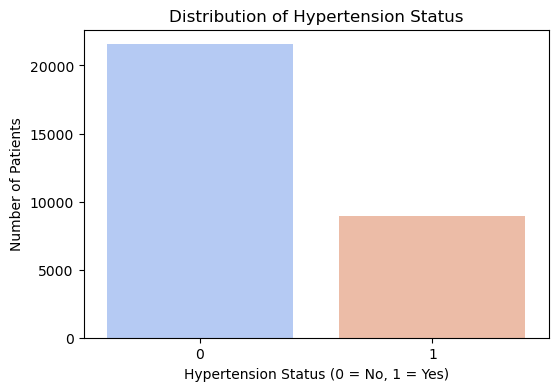

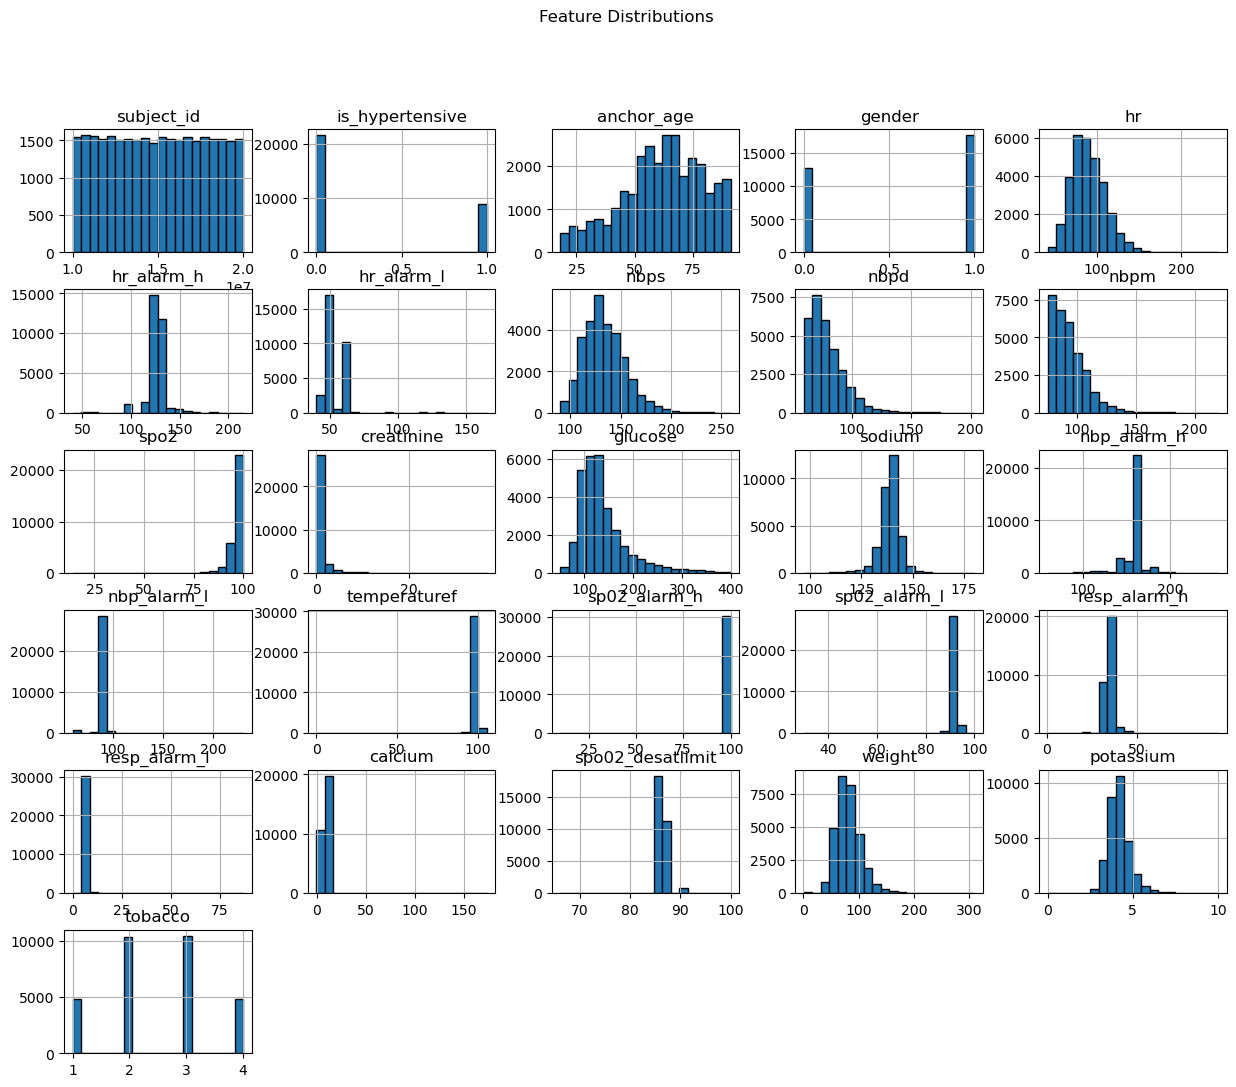

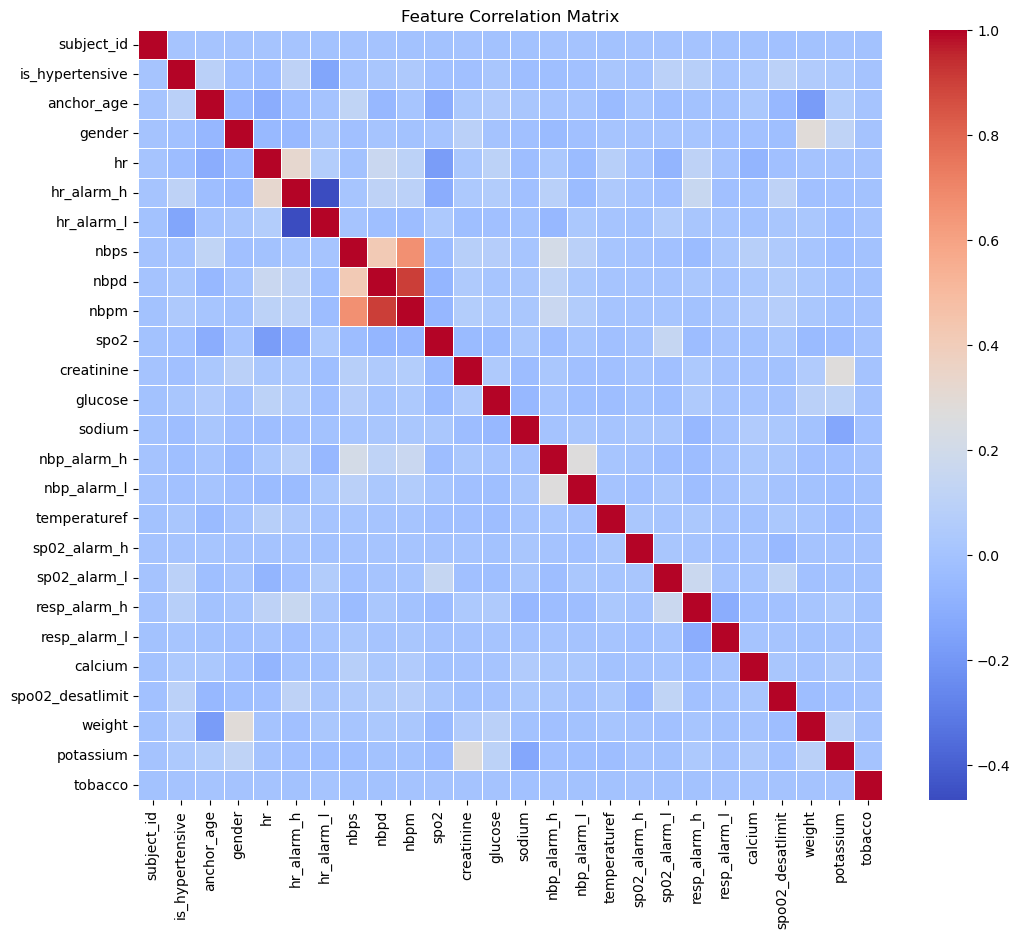

In [7]:
complete_data = pd.read_csv('./complete_data.csv')

# 1. Distribution of the Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(x='is_hypertensive', data=complete_data, hue='is_hypertensive', palette='coolwarm', legend=False)
plt.title("Distribution of Hypertension Status")
plt.xlabel("Hypertension Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()

# 3. Histograms for Feature Distributions
complete_data.hist(figsize=(15, 12), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions")
plt.show()

# 4. Filter the DataFrame to include only numeric columns
numeric_data = complete_data.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()